# Does the monotonicity metric respect negation?

This notebook audits one required property of a directional monotonicity metric:

$$Up(Q)=Down(\neg Q), \qquad Down(Q)=Up(\neg Q).$$

The identities should hold separately for the left and right arguments. They follow from the definitions: an upward violation for $Q$ is exactly a downward violation for $\neg Q$ on the same ordered pair of models.

The audit recomputes the metric directly from `measures.py`. It does **not** use neural-network outcomes.

> **Scope clarification:** complement invariance is a desirable design property, not a theorem that every graded monotonicity measure must satisfy. The manuscript's closure/majorant measure coherently preserves order duality but lacks this property. See `monotonicity_measure_variants_walkthrough.ipynb` for the closure/interior derivation and a two-sided entropy measure that preserves both symmetries.

## Terms used in this audit

| Term | Definition |
|---|---|
| **Complement pair** | Two truth vectors with `not_Q == 1 - Q` at every model in the measurement universe. |
| **Mirror identity** | One required equality, such as `right_up(Q) == right_down(not Q)`. There are four identities per pair. |
| **Signed mirror error** | Left side minus right side of a mirror identity. |
| **Maximum absolute mirror error** | Largest absolute error among the four identities for one pair. Zero means all four pass. |
| **Entropy metric** | The implemented score `1 - H(Q | P) / H(Q)`, where `P` indicates whether a model has at least one true predecessor or successor. |
| **Violation control** | A simple diagnostic score based on explicit monotonicity violations. It is included to check whether the same universe can support exact mirror symmetry. |

A polarity or leaning score is deliberately not used to decide whether the metric passes. Subtracting upward from downward can hide equal errors through cancellation; the four component identities cannot.

In [1]:
from pathlib import Path
from types import SimpleNamespace
import os
import sys
import warnings

import dill as pkl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

start = Path.cwd().resolve()
ROOT = next(
    path for path in [start, *start.parents]
    if (path / "scripts" / "negation_pair_test.py").exists()
)
ARCHIVE = Path.home() / "Documents/UWLing/altk/src/examples"
if not ARCHIVE.exists():
    raise FileNotFoundError(
        f"Archived expression data not found at {ARCHIVE}. Set ARCHIVE to the "
        "old altk/src/examples directory."
    )

# The pickles and metric module were created with the archived package layout.
sys.path.insert(0, str(ARCHIVE))
original_cwd = Path.cwd()
os.chdir(ARCHIVE)
try:
    from ultk.util.frozendict import FrozenDict
    FrozenDict.__setitem__ = dict.__setitem__
    from learn_quant import measures
finally:
    os.chdir(original_cwd)

CFG = SimpleNamespace(
    measures=SimpleNamespace(monotonicity=SimpleNamespace(debug=False))
)
print("analysis root:", ROOT)
print("metric module:", Path(measures.__file__).resolve())

analysis root: /Users/radmajik/Documents/UWLing/ultk-fresh/src/examples/learn_quant
metric module: /Users/radmajik/Documents/UWLing/altk/src/examples/learn_quant/measures.py


## 1. What the implemented metric computes

For upward monotonicity, the code creates a binary predictor $P_{up,Q}(m)$:

$$P_{up,Q}(m)=1 \quad\text{iff some predecessor of }m\text{ is true under }Q.$$

For downward monotonicity it reverses the order and asks whether some successor is true. The score is normalized mutual information between the truth label and that existential predictor:

$$1-\frac{H(Q\mid P)}{H(Q)}.$$

This is not a direct count of monotonicity-preserving or monotonicity-violating ordered pairs.

In [2]:
import inspect

print(inspect.getsource(measures.get_preds))
print(inspect.getsource(measures.has_true_pred))
print("Entropy metric source: measures.py lines 32-117 in this repository.")

def get_preds(num_arr, num, flip=False):
    """Given an array of ints, and an int, get all predecessors of the
    model corresponding to int.
    Returns an array of same shape as num_arr, but with bools
    """
    if not flip:
        return num_arr & num == num_arr
    else:
        return num_arr & num == num

def has_true_pred(num_arr, ref_model_ints, quantifier, num, r_num, flip=False):
    preds = get_preds(num_arr, num, flip)
    #print(num)
    #print(np.stack([quantifier, preds, has_same_base_model(ref_model_ints, r_num)], axis=1))
    return np.any(quantifier * (preds * has_same_base_model(ref_model_ints, r_num)))

Entropy metric source: measures.py lines 32-117 in this repository.


## 2. Load exact complement pairs

The expression pool contains truth vectors over the 256-model `M4/X4` universe used by the monotonicity calculation. We locate pairs among the 2,000 trained expressions, but neural training results play no role in this audit.

In [3]:
base = ARCHIVE / "learn_quant/outputs/M4/X4/d5"
universe = pkl.load(open(base / "master_universe.pkl", "rb"))
pool = pkl.load(open(base / "generated_expressions_xidx.pkl", "rb"))
refs = universe.referents

terms, vectors = [], []
for _, expression in pool.items():
    terms.append(expression.term_expression)
    vectors.append(np.fromiter(
        (expression.meaning.mapping[ref] for ref in refs),
        dtype=int,
        count=len(refs),
    ))
truth = np.array(vectors)

sample = pd.read_csv(ROOT / "expressions_sample_2k.csv")
term_to_index = {term: i for i, term in enumerate(terms)}
sample_indices = [term_to_index[term] for term in sample["term_expression"]]
sample_set = set(sample_indices)
truth_to_index = {row.astype(bool).tobytes(): i for i, row in enumerate(truth)}

pairs, seen = [], set()
for i in sample_indices:
    j = truth_to_index.get((~truth[i].astype(bool)).tobytes())
    if j is not None and j in sample_set:
        pair = (min(i, j), max(i, j))
        if pair not in seen:
            seen.add(pair)
            pairs.append(pair)

assert all(np.array_equal(truth[j], 1 - truth[i]) for i, j in pairs)
print("expression-pool meanings:", len(terms))
print("models in metric universe:", len(refs))
print("exact complement pairs in trained sample:", len(pairs))

expression-pool meanings: 9550
models in metric universe: 256
exact complement pairs in trained sample: 44


## 3. Recompute all four directional scores

For every exact pair $(Q,\neg Q)$, test:

1. `right_up(Q) == right_down(not Q)`
2. `left_up(Q) == left_down(not Q)`
3. `right_down(Q) == right_up(not Q)`
4. `left_down(Q) == left_up(not Q)`

The tolerance for an exact numerical pass is $10^{-12}$.

In [4]:
all_models = universe.binarize_referents(mode="set_vectors_w_padding")
reference_A = universe.binarize_referents(mode="A")
reference_B = universe.binarize_referents(mode="B")

def entropy_scores(q):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        return np.array([
            measures.upward_monotonicity_entropy(all_models, reference_A, q, CFG, False),
            measures.upward_monotonicity_entropy(all_models, reference_B, q, CFG, False),
            measures.upward_monotonicity_entropy(all_models, reference_A, q, CFG, True),
            measures.upward_monotonicity_entropy(all_models, reference_B, q, CFG, True),
        ])

rows = []
for i, j in pairs:
    q = entropy_scores(truth[i])
    not_q = entropy_scores(truth[j])
    rows.append({
        "term_Q": terms[i],
        "term_not_Q": terms[j],
        "right_up_Q": q[0], "left_up_Q": q[1],
        "right_down_Q": q[2], "left_down_Q": q[3],
        "right_up_not_Q": not_q[0], "left_up_not_Q": not_q[1],
        "right_down_not_Q": not_q[2], "left_down_not_Q": not_q[3],
        "error_right_up_vs_not_down": q[0] - not_q[2],
        "error_left_up_vs_not_down": q[1] - not_q[3],
        "error_right_down_vs_not_up": q[2] - not_q[0],
        "error_left_down_vs_not_up": q[3] - not_q[1],
    })

audit = pd.DataFrame(rows)
error_columns = [column for column in audit if column.startswith("error_")]
audit["max_abs_mirror_error"] = audit[error_columns].abs().max(axis=1)
audit["mean_abs_mirror_error"] = audit[error_columns].abs().mean(axis=1)
audit = audit.sort_values("max_abs_mirror_error", ascending=False).reset_index(drop=True)
audit.to_csv(ROOT / "analysis/monotonicity_metric_mirror_audit.csv", index=False)

summary = pd.DataFrame({
    "result": [
        "Exact truth-complement pairs tested",
        "Pairs passing all four identities",
        "Pairs with maximum error > 0.05",
        "Pairs with maximum error > 0.10",
        "Largest observed error",
    ],
    "value": [
        len(audit),
        (audit["max_abs_mirror_error"] < 1e-12).sum(),
        (audit["max_abs_mirror_error"] > 0.05).sum(),
        (audit["max_abs_mirror_error"] > 0.10).sum(),
        audit["max_abs_mirror_error"].max(),
    ],
})
display(summary)

,result,value
0,Exact truth-complement pairs tested,44.00000
1,Pairs passing all four identities,2.00000
2,Pairs with maximum error > 0.05,37.00000
3,Pairs with maximum error > 0.10,33.00000
4,Largest observed error,0.78849


,mirror identity,exact passes (of 44),mean absolute error,maximum absolute error
0,right up(Q) = right down(not Q),9,0.198,0.629
1,left up(Q) = left down(not Q),14,0.192,0.597
2,right down(Q) = right up(not Q),13,0.186,0.788
3,left down(Q) = left up(not Q),13,0.170,0.711


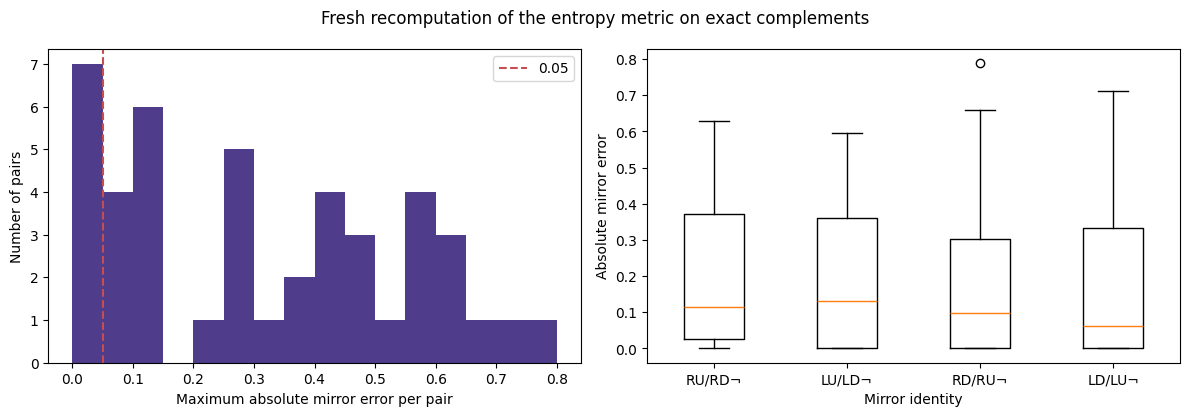

In [5]:
component_summary = pd.DataFrame({
    "mirror identity": [
        "right up(Q) = right down(not Q)",
        "left up(Q) = left down(not Q)",
        "right down(Q) = right up(not Q)",
        "left down(Q) = left up(not Q)",
    ],
    "exact passes (of 44)": [(audit[column].abs() < 1e-12).sum() for column in error_columns],
    "mean absolute error": [audit[column].abs().mean() for column in error_columns],
    "maximum absolute error": [audit[column].abs().max() for column in error_columns],
})
display(component_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].hist(audit["max_abs_mirror_error"], bins=np.linspace(0, 0.8, 17), color="#4f3d8b")
axes[0].axvline(0.05, color="#c44e52", linestyle="--", label="0.05")
axes[0].set(xlabel="Maximum absolute mirror error per pair", ylabel="Number of pairs")
axes[0].legend()

errors_long = audit[error_columns].abs().melt(var_name="identity", value_name="absolute error")
axes[1].boxplot(
    [errors_long.loc[errors_long["identity"] == column, "absolute error"] for column in error_columns],
    labels=["RU/RD¬", "LU/LD¬", "RD/RU¬", "LD/LU¬"],
)
axes[1].set(ylabel="Absolute mirror error", xlabel="Mirror identity")
fig.suptitle("Fresh recomputation of the entropy metric on exact complements")
fig.tight_layout()
plt.show()

### Complete pair table

The table is sorted from the largest to the smallest mirror failure. The same data is saved to `analysis/monotonicity_metric_mirror_audit.csv`.

In [6]:
display(audit)

,term_Q,term_not_Q,right_up_Q,left_up_Q,right_down_Q,left_down_Q,right_up_not_Q,left_up_not_Q,right_down_not_Q,left_down_not_Q,error_right_up_vs_not_down,error_left_up_vs_not_down,error_right_down_vs_not_up,error_left_down_vs_not_up,max_abs_mirror_error,mean_abs_mirror_error
0,"and(greater_than(cardinality(A), cardinality(B...","subset_eq(index(cardinality(B), A), index(card...",0.274874,1.000000,0.788490,0.080096,0.000000,0.000000,0.000000,1.000000,0.274874,0.000000,0.788490,0.080096,0.788490,0.285865
1,"and(not(subset_eq(A, B)), greater_than(cardina...","or(subset_eq(A, B), subset_eq(index(cardinalit...",0.629399,0.253983,0.629399,0.710559,0.000000,0.000000,0.000000,0.000000,0.629399,0.253983,0.629399,0.710559,0.710559,0.555835
2,"or(or(subset_eq(A, B), subset_eq(B, A)), subse...","not(or(or(subset_eq(A, B), subset_eq(B, A)), s...",0.000000,0.000000,0.000000,0.000000,0.657896,0.657896,0.365306,0.365306,-0.365306,-0.365306,-0.657896,-0.657896,0.657896,0.511601
3,"and(and(not(subset_eq(B, A)), subset_eq(A, dif...","subset_eq(index(cardinality(intersection(A, B)...",0.379862,0.025376,0.636555,0.957627,0.000000,0.942518,0.276215,0.000000,0.103647,0.025376,0.636555,0.015109,0.636555,0.195172
4,"and(not(subset_eq(B, difference(A, A))), subse...","or(subset_eq(B, difference(A, A)), greater_tha...",0.355823,1.000000,0.622762,0.169071,0.000000,0.000000,0.606794,1.000000,-0.250971,0.000000,0.622762,0.169071,0.622762,0.260701
5,"subset_eq(index(cardinality(B), A), index(card...","not(subset_eq(index(cardinality(B), A), index(...",0.000000,0.000000,0.000000,0.000000,0.372920,0.621323,0.621323,0.344237,-0.621323,-0.344237,-0.372920,-0.621323,0.621323,0.489951
6,"or(and(subset_eq(A, B), not(subset_eq(B, A))),...","or(and(not(subset_eq(A, B)), greater_than(card...",0.013959,0.013959,0.000000,0.000000,0.455014,0.163265,0.408464,0.610553,-0.394506,-0.596595,-0.455014,-0.163265,0.596595,0.402345
7,"or(and(subset_eq(B, A), not(subset_eq(A, B))),...","or(and(not(subset_eq(B, A)), greater_than(card...",0.013959,0.013959,0.000000,0.000000,0.163265,0.455014,0.610553,0.408464,-0.596595,-0.394506,-0.163265,-0.455014,0.596595,0.402345
8,"subset_eq(index(cardinality(B), difference(A, ...","greater_than(cardinality(difference(A, B)), ca...",1.000000,0.000000,0.000000,1.000000,0.027555,1.000000,1.000000,0.555791,0.000000,-0.555791,-0.027555,0.000000,0.555791,0.145837
9,"subset_eq(index(cardinality(A), difference(B, ...","greater_than(cardinality(difference(B, A)), ca...",0.000000,1.000000,1.000000,0.000000,1.000000,0.027555,0.555791,1.000000,-0.555791,0.000000,0.000000,-0.027555,0.555791,0.145837


## 4. Is this merely a numerical edge case?

`measures.py` emits division warnings when its predecessor indicator is constant. The next function recomputes conditional entropy directly by grouping observations. It avoids zero-probability divisions while preserving the same definition.

In [7]:
def entropy(values):
    _, counts = np.unique(values, return_counts=True)
    probabilities = counts / counts.sum()
    return -(probabilities * np.log2(probabilities)).sum()

def safe_entropy_metric(reference_models, q, flip=False):
    q = np.asarray(q, dtype=int)
    predictor = measures.get_true_predecessors(
        all_models, reference_models, q, flip
    )
    marginal_entropy = entropy(q)
    if marginal_entropy == 0:
        return 1.0
    conditional_entropy = sum(
        (predictor == value).mean() * entropy(q[predictor == value])
        for value in np.unique(predictor)
    )
    return 1 - conditional_entropy / marginal_entropy

def safe_scores(q):
    return np.array([
        safe_entropy_metric(reference_A, q, False),
        safe_entropy_metric(reference_B, q, False),
        safe_entropy_metric(reference_A, q, True),
        safe_entropy_metric(reference_B, q, True),
    ])

maximum_score_difference = 0.0
safe_pair_errors = []
for i, j in pairs:
    old_q, old_not_q = entropy_scores(truth[i]), entropy_scores(truth[j])
    safe_q, safe_not_q = safe_scores(truth[i]), safe_scores(truth[j])
    maximum_score_difference = max(
        maximum_score_difference,
        np.abs(np.r_[old_q - safe_q, old_not_q - safe_not_q]).max(),
    )
    safe_pair_errors.append([
        safe_q[0] - safe_not_q[2], safe_q[1] - safe_not_q[3],
        safe_q[2] - safe_not_q[0], safe_q[3] - safe_not_q[1],
    ])

safe_pair_errors = np.abs(np.array(safe_pair_errors))
display(pd.DataFrame({
    "check": [
        "Maximum original-vs-safe score difference",
        "Pairs passing all mirrors under safe calculation",
        "Pairs with safe mirror error > 0.05",
    ],
    "result": [
        maximum_score_difference,
        (safe_pair_errors.max(axis=1) < 1e-12).sum(),
        (safe_pair_errors.max(axis=1) > 0.05).sum(),
    ],
}))

,check,result
0,Maximum original-vs-safe score difference,2.220446e-16
1,Pairs passing all mirrors under safe calculation,2.000000e+00
2,Pairs with safe mirror error > 0.05,3.700000e+01


**Interpretation:** the safe implementation matches the original to floating-point precision, and the mirror failures remain. The warnings should still be cleaned up, but they do not explain this result.

## 5. Why should we expect symmetry—and why does this formula not guarantee it?

There are two separate claims here. The first is a theorem about **monotonicity itself**. The second concerns whether this particular numerical proxy preserves that theorem.

### 5a. The underlying monotonicity conditions really are symmetric

Take any comparable pair of models $x\preceq y$. Downward monotonicity of $Q$ requires:

$$Q(y)=1 \Longrightarrow Q(x)=1.$$

Upward monotonicity of $\neg Q$ requires:

$$\neg Q(x)=1 \Longrightarrow \neg Q(y)=1.$$

These are the same implication after substituting $\neg Q(z)=1-Q(z)$. Equivalently, their violations are identical:

$$\underbrace{Q(x)=0,\ Q(y)=1}_{\text{downward violation of }Q}
\quad\Longleftrightarrow\quad
\underbrace{\neg Q(x)=1,\ \neg Q(y)=0}_{\text{upward violation of }\neg Q}.$$

Therefore, if a degree measure is a function of those same violation pairs, `down(Q)` and `up(not Q)` must match. This semantic equivalence—not merely the fact that the labels are complements—is why mirror symmetry is expected of a directional monotonicity measure.

### 5b. The implementation does not score those violation pairs

Instead, the entropy metric first replaces the full order relation around each model $m$ with one yes/no feature. For downward $Q$ it asks whether **any true successor exists**:

$$D_Q(m)=1 \iff \exists y\succeq m: Q(y)=1.$$

For upward $\neg Q$ it asks whether **any true predecessor of the complement exists**, equivalently whether any predecessor is false under $Q$:

$$U_{\neg Q}(m)=1 \iff \exists x\preceq m: \neg Q(x)=1
\iff \exists x\preceq m: Q(x)=0.$$

The two reported degrees are then information scores:

$$Down(Q)=\frac{I(Q;D_Q)}{H(Q)},\qquad
Up(\neg Q)=\frac{I(\neg Q;U_{\neg Q})}{H(\neg Q)}.$$

Complementing the label guarantees $H(Q)=H(\neg Q)$, and mutual information would be unchanged if both scores used the same predictor (or complementary predictors). But they do not: one uses $D_Q$ and the other uses $U_{\neg Q}$.

They are not logical complements. Negating the first statement gives:

$$\neg D_Q(m) \iff \forall y\succeq m: Q(y)=0,$$

which says **every successor is false**. That is not the second statement, which says **some predecessor is false**. The statements inspect opposite sides of $m$ and use different logical quantifiers (`for every` versus `there exists`). They can even both be true at the same model—for example, when there is a false predecessor and a true successor.

### 5c. Minimal three-model example

Consider a chain $a\preceq b\preceq c$ with truth values $Q=(0,1,0)$ and therefore $\neg Q=(1,0,1)$. The only strict downward violation of $Q$ is the pair $(a,b)$: $b$ is true but its smaller model $a$ is false. The only strict upward violation of $\neg Q$ is also $(a,b)$: $a$ is true under $\neg Q$ but the larger model $b$ is false. The semantic violation sets match perfectly.

In [8]:
toy = pd.DataFrame({
    "model": ["a (smallest)", "b", "c (largest)"],
    "Q": [0, 1, 0],
    "not Q": [1, 0, 1],
    "D_Q: some true successor exists": [1, 1, 0],
    "U_notQ: some true predecessor exists": [1, 1, 1],
})
display(toy)

toy_pairs = pd.DataFrame({
    "strict comparable pair": ["a <= b", "a <= c", "b <= c"],
    "downward violation of Q": [True, False, False],
    "upward violation of not Q": [True, False, False],
})
display(toy_pairs)

def information_score(label, predictor):
    label = np.asarray(label)
    predictor = np.asarray(predictor)
    label_entropy = entropy(label)
    conditional_entropy = sum(
        (predictor == value).mean() * entropy(label[predictor == value])
        for value in np.unique(predictor)
    )
    return 1 - conditional_entropy / label_entropy

toy_down = information_score(toy["Q"], toy["D_Q: some true successor exists"])
toy_up_not = information_score(
    toy["not Q"], toy["U_notQ: some true predecessor exists"]
)
display(pd.DataFrame({
    "quantity": ["Down(Q) entropy score", "Up(not Q) entropy score", "mirror error"],
    "value": [toy_down, toy_up_not, toy_down - toy_up_not],
    "why": [
        "D_Q = (1,1,0) carries some information about Q = (0,1,0)",
        "U_notQ = (1,1,1) is constant and carries no information",
        "Different witness features produce different information scores",
    ],
}).round(3))

,model,Q,not Q,D_Q: some true successor exists,U_notQ: some true predecessor exists
0,a (smallest),0,1,1,1
1,b,1,0,1,1
2,c (largest),0,1,0,1


,strict comparable pair,downward violation of Q,upward violation of not Q
0,a <= b,True,True
1,a <= c,False,False
2,b <= c,False,False


,quantity,value,why
0,Down(Q) entropy score,0.274,"D_Q = (1,1,0) carries some information about Q..."
1,Up(not Q) entropy score,0.000,"U_notQ = (1,1,1) is constant and carries no in..."
2,mirror error,0.274,Different witness features produce different i...


The two violation columns are identical, so the underlying monotonicity relation is perfectly mirrored. But the existential feature vectors are `(1,1,0)` and `(1,1,1)`. At model $a$, for example, both features equal 1: $b$ is a true successor under $Q$, while $a$ itself is a true predecessor under $\neg Q$. This single row already proves that the features are not logical complements.

The phrase **“existential feature construction breaks the mirror identity”** means the following: the code compresses all ordered pairs around each model into an OR statement—“does at least one witness exist?” This many-to-one compression is applied toward successors for downward degree and toward predecessors for upward degree. Although the original violation pairs transform exactly under negation, these two differently directed OR summaries do not. Once the summaries differ, their information scores are free to differ too.

“Breaks” therefore does **not** mean that negation stopped complementing the labels, or that the order relation is wrong. It means this intermediate feature engineering step does not preserve a symmetry possessed by the semantic property it is intended to quantify.

In [9]:
worst = audit.iloc[0]
i = term_to_index[worst["term_Q"]]
j = term_to_index[worst["term_not_Q"]]
q, not_q = truth[i], truth[j]

# The largest failure for this pair is right_down(Q) vs right_up(not Q).
true_successor_for_q = measures.get_true_predecessors(
    all_models, reference_A, q, flip=True
)
true_predecessor_for_not_q = measures.get_true_predecessors(
    all_models, reference_A, not_q, flip=False
)
predictor_table = pd.crosstab(
    pd.Series(true_successor_for_q, name="exists true successor for Q"),
    pd.Series(true_predecessor_for_not_q, name="exists true predecessor for not Q"),
    dropna=False,
)

print("Q:", worst["term_Q"])
print("not Q:", worst["term_not_Q"])
print("right_down(Q):", worst["right_down_Q"])
print("right_up(not Q):", worst["right_up_not_Q"])
print("absolute mirror error:", abs(worst["error_right_down_vs_not_up"]))
display(predictor_table)

Q: and(greater_than(cardinality(A), cardinality(B)), not(subset_eq(B, difference(A, A))))
not Q: subset_eq(index(cardinality(B), A), index(cardinality(difference(A, A)), A))
right_down(Q): 0.7884895561525679
right_up(not Q): 0.0
absolute mirror error: 0.7884895561525679


exists true predecessor for not Q,1
exists true successor for Q,
0,167
1,89


In this worst case, every one of the 256 models has a true predecessor under $\neg Q$, so that predictor is constant and contains no information. The true-successor predictor for $Q$ is not constant. Their normalized information scores are therefore 0.000 and 0.788, respectively.

This is the real-data version of the three-model example. The labels are exact complements, but the two witness features have different distributions and therefore different information about those labels.

## 6. Why use a direct-violation control?

Section 5 shows how the implemented proxy can lose symmetry. Section 6 is a **positive control** that asks whether some other part of the setup prevents symmetry: perhaps the finite universe is unbalanced, the encoded order relation is malformed, or exact equality is impossible after normalization.

To isolate those possibilities, the control keeps the same 256 models, truth vectors, left/right reference classes, and predecessor relation. It changes only the summary statistic: instead of constructing a per-model existential witness feature and measuring its information, it directly counts the ordered pairs that violate monotonicity.

For every comparable ordered pair $x\preceq y$:

- $Q$ has an upward violation when $Q(x)=1$ and $Q(y)=0$.
- $\neg Q$ has a downward violation on the **same pair** when $\neg Q(y)=1$ and $\neg Q(x)=0$.

Those conditions are algebraically identical. A score normalized by the same total number of comparable pairs must therefore satisfy the mirror identity exactly.

The logic of the comparison is:

| What stays fixed | Entropy proxy | Positive control |
|---|---|---|
| Models and truth vectors | Same | Same |
| Predecessor/successor relation | Same | Same |
| Direction and argument | Same | Same |
| Intermediate representation | Per-model `exists a true witness` bit | Per-pair violation indicator |
| Aggregation | Normalized mutual information | Proportion of non-violating pairs |

If both methods failed, the problem could lie in the universe or relation. Instead, the direct control passes 44/44 while the entropy proxy passes 2/44. This isolates the failure to the proxy's witness-feature/aggregation design.

The control is **not automatically the best replacement measure**. Pair counting makes its own choices about weighting dense regions of the order and about how gradedness should work. Its role here is narrower: demonstrate that the expected mirror symmetry is coherent and achievable on exactly the same data.

In [10]:
model_ints = measures.binary_to_int(all_models)

def predecessor_relation(reference_models):
    reference_ints = measures.binary_to_int(reference_models)
    return (
        ((model_ints[:, None] & model_ints[None, :]) == model_ints[:, None])
        & (reference_ints[:, None] == reference_ints[None, :])
    )

relations = [predecessor_relation(reference_A), predecessor_relation(reference_B)]

def violation_control_scores(q):
    by_argument = []
    for relation in relations:
        denominator = relation.sum()
        upward_violations = (
            relation & (q[:, None] == 1) & (q[None, :] == 0)
        ).sum()
        downward_violations = (
            relation & (q[:, None] == 0) & (q[None, :] == 1)
        ).sum()
        by_argument.append((
            1 - upward_violations / denominator,
            1 - downward_violations / denominator,
        ))
    # right up, left up, right down, left down
    return np.array([
        by_argument[0][0], by_argument[1][0],
        by_argument[0][1], by_argument[1][1],
    ])

control_errors = []
for i, j in pairs:
    q = violation_control_scores(truth[i])
    not_q = violation_control_scores(truth[j])
    control_errors.append([
        q[0] - not_q[2], q[1] - not_q[3],
        q[2] - not_q[0], q[3] - not_q[1],
    ])

control_errors = np.abs(np.array(control_errors))
display(pd.DataFrame({
    "control result": [
        "Pairs tested",
        "Pairs passing all four mirror identities",
        "Maximum absolute mirror error",
    ],
    "value": [
        len(control_errors),
        (control_errors.max(axis=1) < 1e-12).sum(),
        control_errors.max(),
    ],
}))

,control result,value
0,Pairs tested,44.0
1,Pairs passing all four mirror identities,44.0
2,Maximum absolute mirror error,0.0


## Conclusions

1. **The expected property is correct.** On a fixed universe, a complement-consistent directional monotonicity metric should have zero mirror error.
2. **The implemented entropy metric does not have that property.** Fresh computation on 44 exact complement pairs yields only 2 pairs passing all four identities; 37 have maximum error above 0.05.
3. **This is not caused by the neural data, sampling, stale CSV values, or floating-point handling.** The audit uses exact complement vectors and calls the metric implementation directly. A numerically safe entropy calculation reproduces the same failures.
4. **The source is definitional.** “Exists a true successor for $Q$” and “exists a true predecessor for $\neg Q$” are not dual features. The metric measures how informative those features are, so its upward and downward scores need not mirror under negation.
5. **The universe and order representation can support exact symmetry.** The direct violation control passes all four identities for all 44 pairs with maximum error 0.

### Implication

Directional conclusions based on the current entropy scores should be treated cautiously until the measure is redesigned or explicitly symmetrized. This audit diagnoses the property; it does not choose a replacement measure. A replacement should be validated for complement symmetry, behavior on canonical quantifiers, sensitivity to graded violations, and stability across universe sizes before the learning analyses are rerun.

## 7. The Fix: Two lines in `measure_monotonicity`

The root cause is that the code previously computed downward monotonicity using a **successor-based** existential feature ("does model *m* have a true model above it?"), while upward monotonicity uses a **predecessor-based** feature. These are not symmetric.

**The semantic insight:** "Q is downward-monotone" means exactly the same thing as "¬Q is upward-monotone." Monotonicity direction just depends on which side of the truth table you call True. So the downward computation should call the upward function with the negated quantifier — not a flipped direction parameter.

**One-line summary of the change:**
```
# OLD  — flip changes direction of the partial order search, labels stay same
measure(all_models, ref_A, quantifier, cfg, flip=True)   # right downward

# NEW  — negate labels, keep predecessor-looking direction
measure(all_models, ref_A, 1 - quantifier, cfg)          # right downward
```
This guarantees `down(Q) = up(¬Q)` and `up(Q) = down(¬Q)` **by construction**, because both calls go through the identical code path.


In [11]:
# ── Verify the fix on all complement pairs ──────────────────────────────────
# Recompute using flip=False always, negating the quantifier for downward.
# Expected: max mirror error = 0 across all pairs.

def entropy_scores_fixed(q):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        nq = 1.0 - q
        return np.array([
            measures.upward_monotonicity_entropy(all_models, reference_A, q,  CFG, False),  # right up
            measures.upward_monotonicity_entropy(all_models, reference_B, q,  CFG, False),  # left  up
            measures.upward_monotonicity_entropy(all_models, reference_A, nq, CFG, False),  # right down = up(~q)
            measures.upward_monotonicity_entropy(all_models, reference_B, nq, CFG, False),  # left  down = up(~q)
        ])

fix_rows = []
for i, j in pairs:
    q = entropy_scores_fixed(truth[i])
    not_q = entropy_scores_fixed(truth[j])
    fix_rows.append({
        'term_Q': terms[i], 'term_not_Q': terms[j],
        'e_RU': q[0]-not_q[2], 'e_LU': q[1]-not_q[3],
        'e_RD': q[2]-not_q[0], 'e_LD': q[3]-not_q[1],
    })

fix_audit = pd.DataFrame(fix_rows)
fix_audit['max_error'] = fix_audit[['e_RU','e_LU','e_RD','e_LD']].abs().max(axis=1)

print('=== FIXED scores: mirror error summary ===')
print(f'Max error:   {fix_audit["max_error"].max():.2e}')
print(f'Zero errors: {(fix_audit["max_error"] < 1e-12).sum()}/{len(fix_audit)}')
print(f'>0.05 errors: {(fix_audit["max_error"] > 0.05).sum()}/{len(fix_audit)}')
print()
print('=== ORIGINAL scores (for comparison) ===')
print(f'Max error:   {audit["max_abs_mirror_error"].max():.3f}')
print(f'>0.05 errors: {(audit["max_abs_mirror_error"] > 0.05).sum()}/{len(audit)}')


=== FIXED scores: mirror error summary ===
Max error:   0.00e+00
Zero errors: 44/44
>0.05 errors: 0/44

=== ORIGINAL scores (for comparison) ===
Max error:   0.788
>0.05 errors: 37/44
